# Step 0: Enable GPU in Runtime Settings and Set up Python Execution Paths

1. Click on the menu: `Runtime` → `Change runtime type`.

2. Under `Hardware accelerator`, select: `GPU` (for NVIDIA GPUs like T4, P100, A100 depending on your Colab plan)

3. Click “Save”.

Now, your notebook will run with GPU acceleration.

Next, let's verify GPU availability

In [1]:
# Set up the working directory and import path
import os
import sys

# Get the current directory (should be the project root)
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Add current directory to Python path to ensure imports work
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# Verify we're in the right place
print(f"Python path includes: {current_dir}")
print(f"Files in directory: {os.listdir('.')}")

Current working directory: /Users/niambashambu/Desktop/CS 4100/CS4100_project
Python path includes: /Users/niambashambu/Desktop/CS 4100/CS4100_project
Files in directory: ['language_model.py', '.DS_Store', 'knowledge_base.py', 'Resources', 'agent_system.py', 'prompting_techniques.py', 'course-project-introduction.pptx', '__pycache__', 'README.md', '.gitignore', 'Course-Project-Handout.ipynb', 'spec.md', '.git', 'yelp_academic_dataset_business.json']


In [2]:
# Optional: Check GPU availability (if using GPU)
import torch
if torch.cuda.is_available():
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("Running on CPU (GPU not available)")

Running on CPU (GPU not available)


## Environment Setup Complete

The Python import path has been configured. You should now be able to import the Python modules from this directory:
- `knowledge_base.py` - TF-IDF retrieval system
- `language_model.py` - Qwen 2.5-0.5B model wrapper
- `prompting_techniques.py` - ReAct prompt formatting
- `agent_system.py` - Agent controller

In [3]:
# Verify imports are working
try:
    from knowledge_base import CORPUS
    print(f"✓ Successfully imported knowledge_base")
    print(f"  Corpus size: {len(CORPUS)} businesses")
except ImportError as e:
    print(f"✗ Error importing knowledge_base: {e}")

[{'id': 'Pns2l4eNsfO8kk83dixA6A', 'title': 'Abby Rappoport, LAC, CMQ', 'text': "1616 Chapala St, Ste 2 Santa Barbara CA 93101 34.4266787 -119.7111968 5.0 7 0 {'ByAppointmentOnly': 'True'} Doctors, Traditional Chinese Medicine, Naturopathic/Holistic, Acupuncture, Health & Medical, Nutritionists None"}, {'id': 'mpf3x-BjTdTEA3yCZrAYPw', 'title': 'The UPS Store', 'text': "87 Grasso Plaza Shopping Center Affton MO 63123 38.551126 -90.335695 3.0 15 1 {'BusinessAcceptsCreditCards': 'True'} Shipping Centers, Local Services, Notaries, Mailbox Centers, Printing Services {'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', 'Wednesday': '8:0-18:30', 'Thursday': '8:0-18:30', 'Friday': '8:0-18:30', 'Saturday': '8:0-14:0'}"}, {'id': 'tUFrWirKiKi_TAnsVWINQQ', 'title': 'Target', 'text': '5255 E Broadway Blvd Tucson AZ 85711 32.223236 -110.880452 3.5 22 0 {\'BikeParking\': \'True\', \'BusinessAcceptsCreditCards\': \'True\', \'RestaurantsPriceRange2\': \'2\', \'CoatCheck\': \'False\', \'RestaurantsTakeOut\': \'

Now let's proceed to the main steps of building the IR agent system.

# Step 1: Set up the Knowledge Base and Implement Search Tools

We will begin with a small corpus of a dataset as an example, and show how we can build a search method that finds the most related document given an input query. We will use this corpus as the database and the method as the action space for building a GPT-based agent.  


The corpus contains Yelp business data loaded from `yelp_academic_dataset_business.json`. Each business entry includes:
- Business ID, name, and categories
- Location information (address, city, state, ZIP)
- Ratings (stars) and review counts
- Attributes and hours

The knowledge base module processes this data and creates searchable documents using TF-IDF vectorization.


In [4]:
# Import the Yelp business corpus
from knowledge_base import CORPUS

print(f"Loaded {len(CORPUS)} businesses from the Yelp dataset")
print(f"\nExample business entry:")
if CORPUS:
    print(f"  ID: {CORPUS[0]['id']}")
    print(f"  Name: {CORPUS[0]['title']}")
    print(f"  Text snippet: {CORPUS[0]['text'][:150]}...")

Loaded 150346 businesses from the Yelp dataset

Example business entry:
  ID: Pns2l4eNsfO8kk83dixA6A
  Name: Abby Rappoport, LAC, CMQ
  Text snippet: 1616 Chapala St, Ste 2 Santa Barbara CA 93101 34.4266787 -119.7111968 5.0 7 0 {'ByAppointmentOnly': 'True'} Doctors, Traditional Chinese Medicine, Nat...


Then, we design a simple search method based on **TF-IDF** to retrieve information from the corpus.

TF-IDF (Term Frequency–Inverse Document Frequency) is a method to find the most relevant passages for a query.
1. We will tokenize each document and the query into words.
2. We will compute TF (Term Frequency) to measure how often a word appears in a document. More frequent indicates more important within that document.
3. We will compute IDF (Inverse Document Frequency), which is used to downweight words that are common across many documents, like “the” or “and,” and upweight rarer words.
4. We will compute TF-IDF vectors (containing the TF-IDF score for each word) for both documents and the query.
5. We will compute cosine similarity between the query vector and each document vector.
6. We will implement a search method that finds the documents with the highest similarity scores as the top-k search results.

We note that this action space can mostly only retrieve a small part of a passage based on the exact passage name, which is weaker than state-of-the-art retrievers. The purpose is to simulate how the search method in Wikipedia and make models to retrieve via reasoning in language.

As an extension of the project, you can redefine the search method in this code snippet to incorporate a more powerful search method.


In [5]:
from knowledge_base import DF, IDF, DOC_VECS, search_corpus, TOOLS

Now, let's test the python files in the first step we write

In [6]:
# let's look at the scores for the words
import pandas as pd

# Show a few common and rare terms with DF and IDF
terms_df = pd.DataFrame(
    [(t, DF[t], round(IDF[t], 3)) for t in sorted(DF.keys())],
    columns=["term", "df", "idf"]
).sort_values(by="idf", ascending=False)

# Build a dense matrix (terms x docs) for inspection (only top 20 idf terms for readability)
top_terms = list(terms_df["term"].head(20))
matrix = []
for t in top_terms:
    row = []
    for vec in DOC_VECS:
        row.append(vec.get(t, 0.0))
    matrix.append(row)

tfidf_table = pd.DataFrame(
    matrix,
    index=top_terms,
    columns=[d["id"] for d in CORPUS]
)

# Print the first 20 tf-idf scores for each document. We will use these scores to compute similarity between
tfidf_table[:20]


,Pns2l4eNsfO8kk83dixA6A,mpf3x-BjTdTEA3yCZrAYPw,tUFrWirKiKi_TAnsVWINQQ,MTSW4McQd7CbVtyjqoe9mw,mWMc6_wTdE0EUBKIGXDVfA,CF33F8-E6oudUQ46HnavjQ,n_0UpQx1hsNbnPUSlodU8w,qkRM_2X51Yqxk3btlwAQIg,k0hlBqXX-Bt0vf1op7Jr1w,bBDDEgkFA1Otx9Lfe7BZUQ,...,WnT9NIzQgLlILjPT0kEcsQ,x_2IrYgFiQn7GOTTgWRbAw,fn3ybdsRSrIDpKZTsRuAWg,2O2K6SXPWv56amqxCECd4w,hn9Toz3s-Ei3uZPt7esExA,IUQopTMmYQG-qRtBk-8QnA,c8GjPIOTGVmIemT7j5_SyQ,_QAMST-NrQobXduilWEqSw,mtGm22y5c2UHNXDFAjaPNw,jV_XOycEzSlTx-65W906pg
607069,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7625569,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7625993468,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
762594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7625879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7625768192,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7625669,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
762557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7625464,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7626029,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


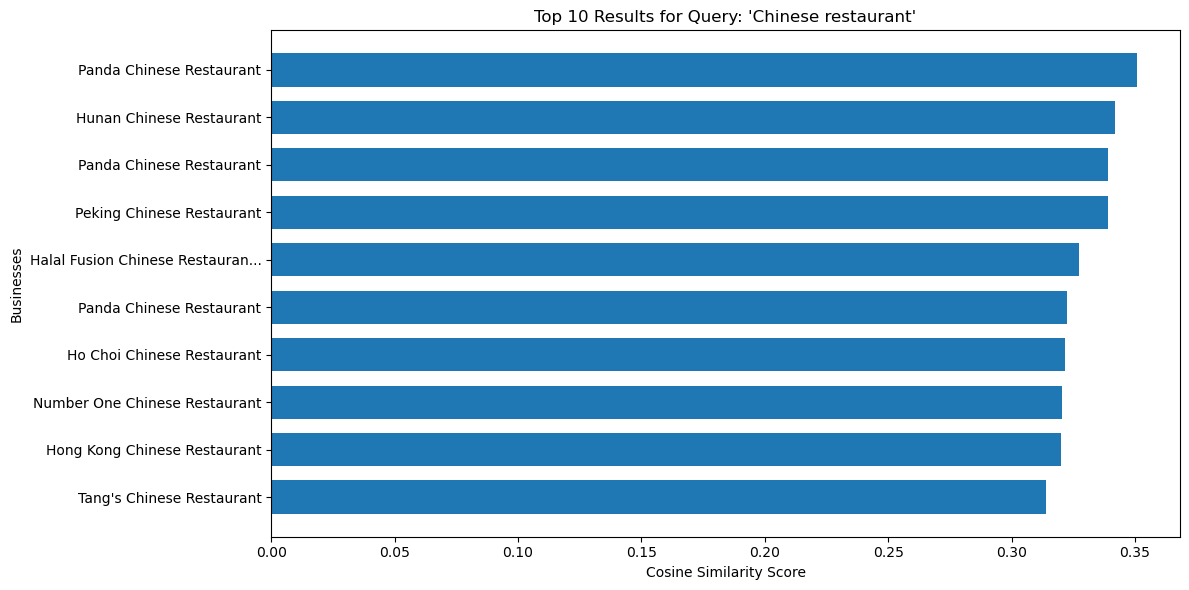


Top 5 results for 'Chinese restaurant':
1. Panda Chinese Restaurant (score: 0.3507)
2. Hunan Chinese Restaurant (score: 0.3417)
3. Panda Chinese Restaurant (score: 0.3392)
4. Peking Chinese Restaurant (score: 0.3391)
5. Halal Fusion Chinese Restaurant (score: 0.3271)


In [7]:
# Now, let's visualize scores for a Yelp business query
import matplotlib.pyplot as plt

# Example query: search for Chinese restaurants
q = "Chinese restaurant"
topk = search_corpus(q, k=min(10, len(CORPUS)))  # Top 10 for visualization
labels = [item['title'][:30] + ('...' if len(item['title']) > 30 else '') for item in topk]
vals = [item['score'] for item in topk]

plt.figure(figsize=(12, 6))
plt.barh(range(len(labels)), vals, height=0.7)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Businesses")
plt.title(f"Top {len(topk)} Results for Query: '{q}'")
plt.gca().invert_yaxis()  # Highest score at top
plt.tight_layout()
plt.show()

print(f"\nTop 5 results for '{q}':")
for i, item in enumerate(topk[:5], 1):
    print(f"{i}. {item['title']} (score: {item['score']:.4f})")

# Step 2: Designing Prompting Techniques

We will build ReAct prompting, which extends that idea by mixing the model's written thoughts with actions.

- Recall that the agent model follows a loop (Thought → Action → Observation) where it first using chain-of-thought prompting about what to do, then takes an action, reads the result, and repeats until it is ready to answer.
- We will define a prompting format that explicitly concatnate Thought, Action, Observation into a prompt:

In [8]:
from prompting_techniques import parse_action, make_prompt

Let's do some quick tests about the functions we write


In [9]:
import json

samples = [
    'Action: yelp_search[location="Boston", term="pizza", k=3]',
    'Action: finish[answer="Regina Pizzeria is highly rated."]',
    'Action: yelp_details[business_id="abcd1234"]',
]

print("### Parsing Yelp Actions ###")
for line in samples:
    parsed = parse_action(line)
    print(f"{line}\n -> {parsed}\n")

print("Invalid line parse:", parse_action("Action: ???"))
print("\n")


# --- Building a Yelp-style trajectory ---
trajectory = [
    {
        "thought": "I should search Yelp for the highest-rated pizza spots in Boston.",
        "action": 'yelp_search[location="Boston", term="pizza", k=3]',
        "observation": json.dumps({
            "results": [
                {"name": "Regina Pizzeria", "rating": 4.7, "review_count": 2891},
                {"name": "Santarpio’s Pizza", "rating": 4.6, "review_count": 1982},
                {"name": "Picco", "rating": 4.5, "review_count": 1350}
            ]
        })
    },
    {
        "thought": "I now have enough Yelp data to answer.",
        "action": 'finish[answer="Regina Pizzeria, Santarpio’s Pizza, and Picco are top-rated."]',
        "observation": "done"
    }
]

prompt = make_prompt("What are the best pizza places in Boston?", trajectory)

# Show the last few lines so you can confirm the format cue ends with 'Thought:'
print("\n--- Prompt ---")
print("\n".join(prompt.splitlines()[-12:]))

### Parsing Yelp Actions ###
Action: yelp_search[location="Boston", term="pizza", k=3]
 -> ('yelp_search', {'location': 'Boston', 'term': 'pizza', 'k': 3})

Action: finish[answer="Regina Pizzeria is highly rated."]
 -> ('finish', {'answer': 'Regina Pizzeria is highly rated.'})

Action: yelp_details[business_id="abcd1234"]
 -> ('yelp_details', {'business_id': 'abcd1234'})

Invalid line parse: None



--- Prompt ---
Action: <one of the tool calls above, or finish[...]>

User Question: What are the best pizza places in Boston?

Thought: I should search Yelp for the highest-rated pizza spots in Boston.
Action: yelp_search[location="Boston", term="pizza", k=3]
Observation: {"results": [{"name": "Regina Pizzeria", "rating": 4.7, "review_count": 2891}, {"name": "Santarpio\u2019s Pizza", "rating": 4.6, "review_count": 1982}, {"name": "Picco", "rating": 4.5, "review_count": 1350}]}
Thought: I now have enough Yelp data to answer.
Action: finish[answer="Regina Pizzeria, Santarpio’s Pizza, and Pic

# Step 3: Building a Language Model Interface

Next, we will load a language model as the base model for the agent system. We will define the interaction between the language model and the knowledge base/external tools, using the above prompting format.

In this step, we will complete the following implementations
- We will load a GPT-style model from the Huggingface website, which stores many open-source language models. We will use a small pretrained language model as the base for our agent system.
- We will use the language model and the prompt format designed above to generate thoughts and actions for the task.


Specifically, given a user prompt, the language model is expected to return exactly the two lines:
```
Thought: …

Action: search[query="..."] or Action: finish[answer="..."]
```
With this, we can integrate our language model with the tools to solve a task



In [10]:
from language_model import LLM

`torch_dtype` is deprecated! Use `dtype` instead!


Let's do a test of the LLM that we define

In [11]:
# Test the LLM with a Yelp business query
example_user_query = "What are the best Italian restaurants?"
prompt = make_prompt(example_user_query, trajectory=[])

# Let's use the LLM to generate some output
print("====== Testing LLM Output ======")
print(f"Query: {example_user_query}\n")
example_output = LLM(prompt)
print("LLM Response:")
print(example_output)

====== Testing LLM Output ======
Query: What are the best Italian restaurants?



/Users/niambashambu/anaconda3/envs/ds/lib/python3.12/site-packages/transformers/pytorch_utils.py:339: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


LLM Response:
Thought: The best Italian restaurants are located in Rome and are known for their authentic Italian cuisine.
Action: finish[answer="The best Italian restaurants in Rome are located in the Piazza della Signoria, the Piazza del Duomo, and the Piazza Navona. These places offer a variety of authentic Italian dishes, including pasta, pizza, and risotto. Some of the most famous Italian restaurants in Rome include La Scala, the Sotto Fusore, and the Pizzeria del Trattoria."]


# Step 4: Integrating Components into an Agent System
Finally, we will put everything together as an agent system, including the external database, the information search tools, and a base language model.
- The agent will take the input and use a language model to output the Thought and Action.
- The agent will execute the Action (which in this case is searching for a document) and concatenate the returned document as Observation to the next round of the prompt
- The agent will iterate over the above two steps until it identifies the answer or reaches an iteration limit.



In [12]:
from agent_system import ReActAgent, AgentConfig

# Demo Run

Finally, we will launch the system for a user query “Who painted The Starry Night and where was it painted?”

In [13]:
# ----------------------------
# Demo Run: Complete Agent System
# ----------------------------
from typing import Callable, Dict, List, Tuple, Optional, Any

# Initialize the agent with LLM, tools, and configuration
agent = ReActAgent(LLM, TOOLS, AgentConfig(max_steps=6, verbose=True))

# Example query 1: Search for pizza places
print("=" * 80)
print("DEMO 1: Pizza Restaurant Search")
print("=" * 80)
demo_q1 = "What are the best pizza restaurants?"
result1 = agent.run(demo_q1)

print(f"\nQuestion: {result1['question']}")
print(f"\nFinal Answer: {result1['final_answer']}")
print(f"\nTrajectory ({len(result1['steps'])} steps):")
for i, s in enumerate(result1["steps"], 1):
    print(f"\n--- Step {i} ---")
    print(f"Thought: {s['thought']}")
    print(f"Action: {s['action']}")
    obs = s['observation']
    if len(obs) > 300:
        obs = obs[:300] + "..."
    print(f"Observation: {obs}")

# Example query 2: Search for Chinese restaurants
print("\n" + "=" * 80)
print("DEMO 2: Chinese Restaurant Search")
print("=" * 80)
demo_q2 = "Find highly rated Chinese restaurants"
result2 = agent.run(demo_q2)

print(f"\nQuestion: {result2['question']}")
print(f"\nFinal Answer: {result2['final_answer']}")
if result2['final_answer']:
    print(f"\n✓ Agent successfully generated an answer!")
else:
    print(f"\n⚠ Agent did not generate a final answer in {len(result2['steps'])} steps")
    print(f"Last step action: {result2['steps'][-1]['action'] if result2['steps'] else 'None'}")

# Example query 3: Location-based search
print("\n" + "=" * 80)
print("DEMO 3: Location-Based Search")
print("=" * 80)
demo_q3 = "What are good Italian restaurants near downtown?"
result3 = agent.run(demo_q3)

print(f"\nQuestion: {result3['question']}")
print(f"\nFinal Answer: {result3['final_answer']}")

# Display retrieved businesses from the search
if result3['steps']:
    for step in result3['steps']:
        if 'search' in step['action'].lower() and step['observation']:
            try:
                import json
                obs_data = json.loads(step['observation'])
                if 'results' in obs_data:
                    print(f"\nRetrieved {len(obs_data['results'])} businesses:")
                    for idx, biz in enumerate(obs_data['results'][:5], 1):
                        print(f"  {idx}. {biz.get('title', 'Unknown')}")
            except:
                pass

print("\n" + "=" * 80)
print("Demo Complete!")
print("=" * 80)


DEMO 1: Pizza Restaurant Search

Question: What are the best pizza restaurants?

Final Answer: None

Trajectory (6 steps):

--- Step 1 ---
Thought: I should search for key facts related to the question.
Action: Action: search[query="(auto) refine the user question", k=3]
Observation: {"tool": "search", "query": "(auto) refine the user question", "results": [{"id": "08zL0CHz6CwcCmbI4sT3ZA", "title": "Refine Classic Barbershop", "snippet": "2231 N Mount Juliet Rd Mount Juliet TN 37122 36.2013017 -86.5180891 4.5 27 1 {'RestaurantsPriceRange2': '2', 'BikeParking': 'True', 'BusinessP...

--- Step 2 ---
Thought: I have found multiple restaurants that cater to various price ranges and types of services. I will now provide the top 3 results.
Action: Action: search[query="(auto) refine the user question", k=3]
Observation: {"tool": "search", "query": "(auto) refine the user question", "results": [{"id": "08zL0CHz6CwcCmbI4sT3ZA", "title": "Refine Classic Barbershop", "snippet": "2231 N Mount Jul

# Congratulations!

You’ve completed a working demo of an AI agent powered by a GPT-style language model—great job!

Next, consider how to extend this framework with additional capabilities (e.g., richer tools, better retrieval, stronger evaluation, and safety checks). We’ve outlined several concrete directions and resources in the [google doc handout](https://docs.google.com/document/d/1kzaK1K4g8QvxT3sRAVjg7xEXnD5b59NpkbOFBsEZXXk/edit?usp=sharing); see the “Further Development” section for links and examples. Explore, iterate, and have fun!

# Part 5: Frontend Integration

Now that we have a working agent system, let's integrate it with a web frontend. The frontend allows users to interact with the agent through a user-friendly interface.

## Frontend Components

The frontend (`frontend.html`) includes:
- **QueryBar**: Input field for natural language queries with top_k control
- **ReasoningPanel**: Displays LLM reasoning steps (collapsible)
- **ResultsList**: Shows ranked business results
- **ResultCard**: Individual business cards with metadata, ratings, and similarity scores

## API Backend

The FastAPI backend (`api.py`) provides:
- `GET /api/health`: Health check endpoint
- `POST /api/query`: Main query endpoint that returns reasoning steps and business results


In [ ]:
# Step 5.1: Start the API Server

# To start the API server, run this command in a terminal (not in this notebook):
# python api.py
#
# Or use uvicorn directly:
# uvicorn api:app --host 0.0.0.0 --port 8000 --reload
#
# The server will be available at http://localhost:8000
#
# Note: In Jupyter, you can also start it in the background using subprocess
# but it's recommended to run it in a separate terminal for better control.

import subprocess
import sys
import time
import requests

print("To start the API server, run this in a separate terminal:")
print("  python api.py")
print("\nOr:")
print("  uvicorn api:app --host 0.0.0.0 --port 8000 --reload")
print("\nThen open frontend.html in your browser!")
print("\n" + "="*80)


In [ ]:
# Step 5.2: Test the API (if server is running)

# Uncomment and run this cell to test the API endpoint
# Make sure the API server is running first!

"""
try:
    response = requests.post(
        "http://localhost:8000/api/query",
        json={"query": "Best Chinese restaurant", "top_k": 3},
        headers={"Content-Type": "application/json"}
    )
    
    if response.status_code == 200:
        data = response.json()
        print("✓ API Response received!")
        print(f"\nReasoning steps: {len(data.get('reasoning', []))}")
        print(f"Retrieved businesses: {len(data.get('retrieved', []))}")
        
        if data.get('reasoning'):
            print("\nReasoning:")
            for i, step in enumerate(data['reasoning'], 1):
                print(f"  {i}. {step}")
        
        if data.get('retrieved'):
            print("\nBusinesses:")
            for i, biz in enumerate(data['retrieved'], 1):
                print(f"  {i}. {biz['name']} ({biz['stars']} stars, similarity: {biz['similarity_score']:.3f})")
    else:
        print(f"✗ API Error: {response.status_code}")
        print(response.text)
except requests.exceptions.ConnectionError:
    print("✗ Could not connect to API server.")
    print("  Make sure the server is running: python api.py")
except Exception as e:
    print(f"✗ Error: {e}")
"""


## Using the Frontend

1. **Start the API server** in a terminal:
   ```bash
   python api.py
   ```
   The server will start on `http://localhost:8000`

2. **Open the frontend** in your browser:
   - Open `frontend.html` in your web browser
   - Or use a local server: `python -m http.server 3000` and navigate to `http://localhost:3000/frontend.html`

3. **Enter a query** in the frontend:
   - Try queries like "Best Chinese restaurant in South End"
   - Adjust the "Top K" value to control how many results to return
   - Click "Search" to see the results

4. **View the results**:
   - The reasoning panel shows the LLM's thought process
   - Each business card displays name, rating, address, categories, and similarity score
   - Click "View Details" to see more information about each business


In [ ]:
# Step 5.3: Display frontend instructions

from IPython.display import HTML, display
import os

frontend_path = os.path.join(os.getcwd(), "frontend.html")

if os.path.exists(frontend_path):
    print("✓ Frontend file found!")
    print(f"\nTo use the frontend:")
    print(f"1. Start the API server: python api.py")
    print(f"2. Open {frontend_path} in your browser")
    print(f"\nOr use Python's HTTP server:")
    print(f"  python -m http.server 3000")
    print(f"  Then open: http://localhost:3000/frontend.html")
else:
    print("✗ Frontend file not found. Make sure frontend.html exists in the project directory.")
